In [ ]:
# Install dependencies
'''
pydicom -> Used to read medical images which are in DICOM format
albumentations -> Used to apply augmentation to images
timm -> Used to used the pretrained models like EfficientNet
'''
!pip install pydicom albumentations timm -q

In [2]:
# Import libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch: 2.10.0+cu128
CUDA available: True
Device: Tesla T4


In [ ]:
# Load dataset
dataset_location = '/kaggle/input/competitions/siim-isic-melanoma-classification'
jpeg_dir = f'{dataset_location}/jpeg/train'

df = pd.read_csv(f'{dataset_location}/train.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['target'].value_counts()}") # Counts the data based on the label/target
print(f"\nPositive rate: {df['target'].mean()*100:.2f}%") # Finds how many melanoma cases there are

Dataset shape: (33126, 8)

Class distribution:
target
0    32542
1      584
Name: count, dtype: int64

Positive rate: 1.76%


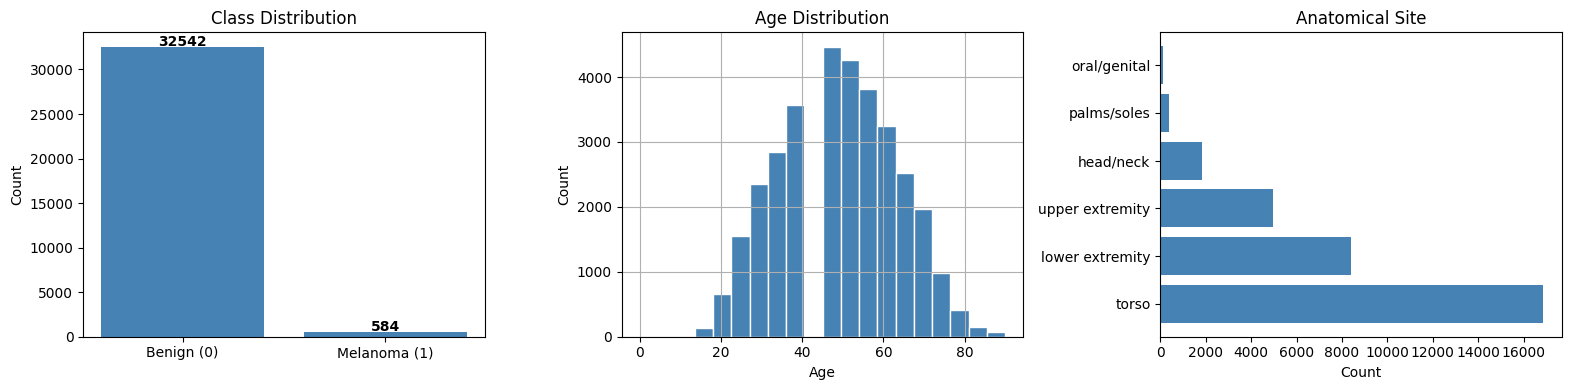

In [4]:
# EDA plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
counts = df['target'].value_counts()
axes[0].bar(['Benign (0)', 'Melanoma (1)'], counts.values, color='steelblue')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Age distribution
df['age_approx'].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

# Anatomical site
site_counts = df['anatom_site_general_challenge'].value_counts()
axes[2].barh(site_counts.index, site_counts.values, color='steelblue')
axes[2].set_title('Anatomical Site')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

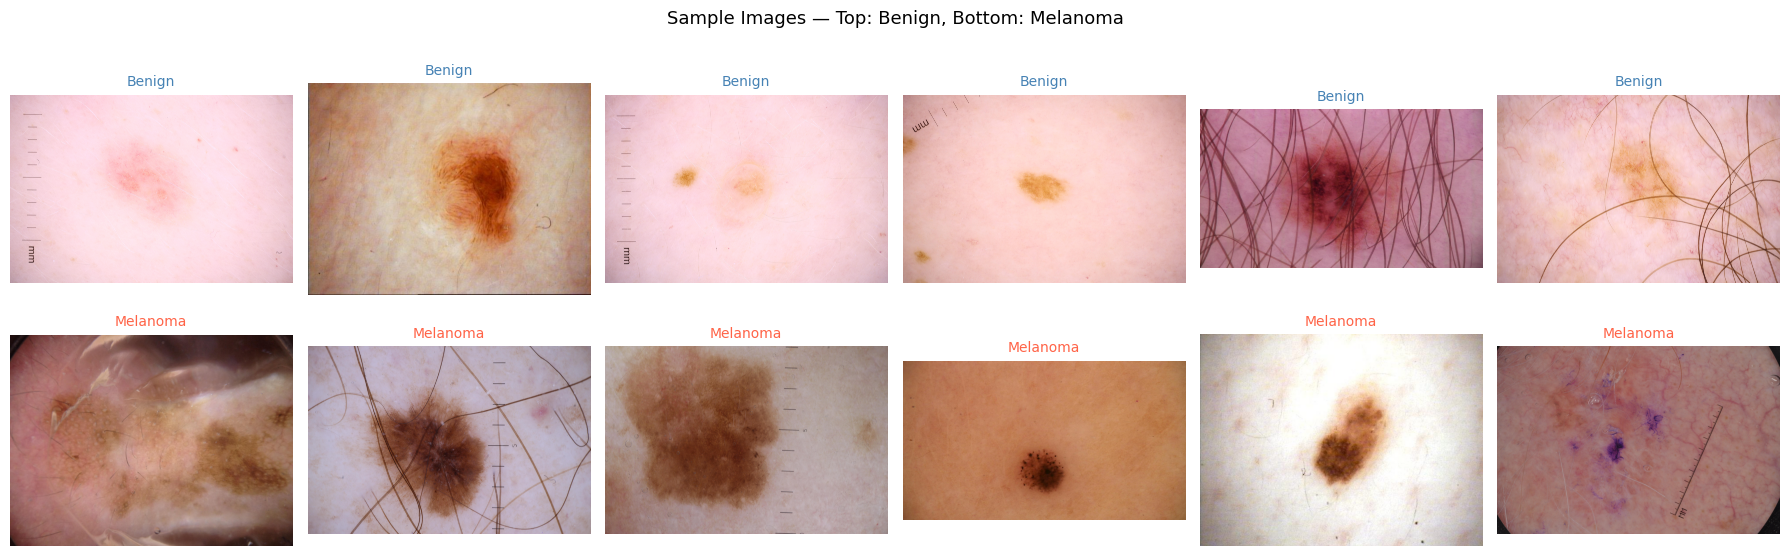

In [ ]:
# Sample images - benign vs melanoma
from PIL import Image

fig, axes = plt.subplots(2, 6, figsize=(18, 6))

# Picks 6 samples from both benign and malignant classes
benign_samples = df[df['target'] == 0].sample(6, random_state=42)
malignant_samples = df[df['target'] == 1].sample(6, random_state=42)

for i, (_, row) in enumerate(benign_samples.iterrows()):
    img = Image.open(f"{jpeg_dir}/{row['image_name']}.jpg") # Open the image
    axes[0][i].imshow(img)
    axes[0][i].set_title('Benign', fontsize=10, color='steelblue')
    axes[0][i].axis('off')

for i, (_, row) in enumerate(malignant_samples.iterrows()):
    img = Image.open(f"{jpeg_dir}/{row['image_name']}.jpg")
    axes[1][i].imshow(img)
    axes[1][i].set_title('Melanoma', fontsize=10, color='tomato')
    axes[1][i].axis('off')

plt.suptitle('Sample Images — Top: Benign, Bottom: Melanoma', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Dataset class that inherits PyTorch Dataset
class MelanomaDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True) # Resets the index number
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx] # Gets row number idx from the dataframe.

        # Load image
        img_path = os.path.join(self.image_dir, row['image_name'] + '.jpg')
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        label = torch.tensor(row['target'], dtype=torch.float32) # Convert the label to PyTorch tensor
        return image, label

In [7]:
# Image transforms
IMAGE_SIZE = 224

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=30, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.CoarseDropout(num_holes_range=(1, 8), hole_height_range=(8, 16), hole_width_range=(8, 16), p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

print("Transforms ready!")

Transforms ready!


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
# Train/val split and dataloaders
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['target'] # Ensures that both splits have same melanoma ratio
)

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"Train melanoma cases: {train_df['target'].sum()}")
print(f"Val melanoma cases:   {val_df['target'].sum()}")

# WeightedRandomSampler to handle class imbalance
class_counts = train_df['target'].value_counts().sort_index()
class_weights = 1.0 / class_counts
sample_weights = train_df['target'].map(class_weights).values # Assigns a weight to every single image in the training set
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Create datasets
train_dataset = MelanomaDataset(train_df, jpeg_dir, transform=train_transform)
val_dataset   = MelanomaDataset(val_df,   jpeg_dir, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,   num_workers=4, pin_memory=True)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Train size: 26500
Val size:   6626
Train melanoma cases: 467
Val melanoma cases:   117

Train batches: 415
Val batches:   104


In [ ]:
# Model class
class MelanomaModel(nn.Module):
    def __init__(self, model_name='efficientnet_b0', pretrained=True):
        super().__init__()

        # Load pretrained backbone from timm
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0  # remove the original classifier head
        )

        num_features = self.backbone.num_features

        # My custom classifier for binary classification
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(num_features, 1)
        )

    def forward(self, x):
        features = self.backbone(x)
        output = self.classifier(features)
        return output

print("Model class ready!")

Model class ready!


In [ ]:
# Training and validation functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1) # Model outputs the shape as (64, 1)

        optimizer.zero_grad() # Clears previous gradients
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step() # Updates all the weights using the gradients calculated in loss.backward()

        running_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx}/{len(loader)} - Loss: {loss.item():.4f}")

    return running_loss / len(loader) # Returns the average loss across all batches for this epoch


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = running_loss / len(loader)
    auc = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc

print("Functions ready!")

Functions ready!


In [11]:
# Model setup - EfficientNet-B0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MelanomaModel('efficientnet_b0', pretrained=True)
model = nn.DataParallel(model)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

print(f"Device: {device}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
print("Model ready!")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Device: cuda
Number of GPUs: 2
Model ready!


In [ ]:
# Training loop with early stopping - EfficientNet-B0
EPOCHS = 10
best_auc = 0.0
patience = 3
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
min_delta = 1e-4

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_auc = validate_epoch(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

    if val_auc > best_auc + min_delta:
        best_auc = val_auc
        patience_counter = 0
        torch.save(model.module.state_dict(), 'efficientnet_b0_best.pth')
        print(f"  New best model saved! AUC: {best_auc:.4f}")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

print(f"\nBest AUC: {best_auc:.4f}")


Epoch 1/10
----------------------------------------
  Batch 0/415 - Loss: 0.7214
  Batch 100/415 - Loss: 0.4160
  Batch 200/415 - Loss: 0.3783
  Batch 300/415 - Loss: 0.1504
  Batch 400/415 - Loss: 0.2174
  Train Loss: 0.3460 | Val Loss: 0.1816 | Val AUC: 0.8654
  New best model saved! AUC: 0.8654

Epoch 2/10
----------------------------------------
  Batch 0/415 - Loss: 0.2501
  Batch 100/415 - Loss: 0.1182
  Batch 200/415 - Loss: 0.1744
  Batch 300/415 - Loss: 0.1613
  Batch 400/415 - Loss: 0.2924
  Train Loss: 0.1620 | Val Loss: 0.1357 | Val AUC: 0.8473
  No improvement. Patience: 1/3

Epoch 3/10
----------------------------------------
  Batch 0/415 - Loss: 0.1165
  Batch 100/415 - Loss: 0.1937
  Batch 200/415 - Loss: 0.1246
  Batch 300/415 - Loss: 0.1541
  Batch 400/415 - Loss: 0.0763
  Train Loss: 0.1026 | Val Loss: 0.1422 | Val AUC: 0.8439
  No improvement. Patience: 2/3

Epoch 4/10
----------------------------------------
  Batch 0/415 - Loss: 0.1465
  Batch 100/415 - Loss: 0.

In [12]:
# Load saved EfficientNet-B0 model
state_dict = torch.load('/kaggle/input/notebooks/anadykhan/aml-project/efficientnet_b0_best.pth')

model_eval = MelanomaModel('efficientnet_b0', pretrained=False).to(device)
model_eval.load_state_dict(state_dict)
model_eval.eval()
print("Model loaded successfully!")

Model loaded successfully!


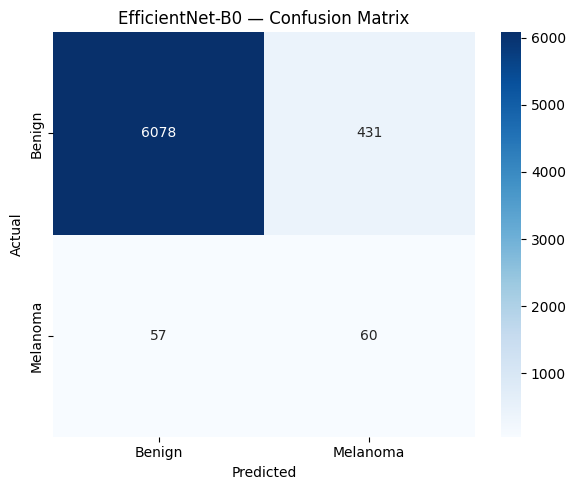

              precision    recall  f1-score   support

      Benign       0.99      0.93      0.96      6509
    Melanoma       0.12      0.51      0.20       117

    accuracy                           0.93      6626
   macro avg       0.56      0.72      0.58      6626
weighted avg       0.98      0.93      0.95      6626



In [13]:
# Confusion matrix and classification report
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_eval(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs > 0.5).float()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Melanoma'],
            yticklabels=['Benign', 'Melanoma'])
plt.title('EfficientNet-B0 — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=['Benign', 'Melanoma']))

In [14]:
# Grad-CAM visualisation
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


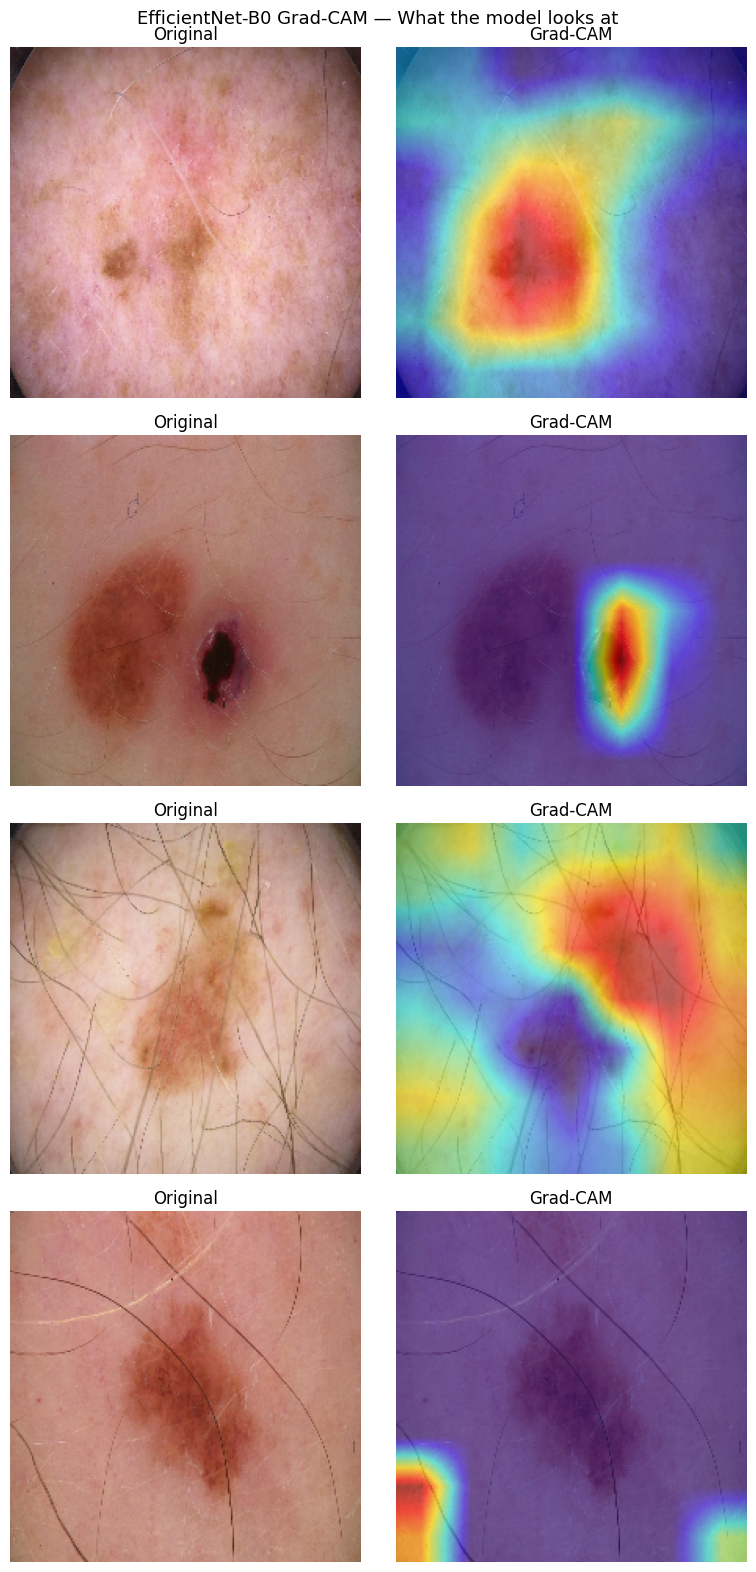

In [15]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget

# Target the last block of EfficientNet
target_layer = [model_eval.backbone.blocks[-1]]
cam = GradCAM(model=model_eval, target_layers=target_layer)

# Get 4 melanoma samples from validation set
melanoma_df = val_df[val_df['target'] == 1].sample(4, random_state=42)

fig, axes = plt.subplots(4, 2, figsize=(8, 16))

for i, (_, row) in enumerate(melanoma_df.iterrows()):
    # Load original image
    img = cv2.imread(f"{jpeg_dir}/{row['image_name']}.jpg")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img_float = img.astype(float) / 255.0

    # Prepare tensor
    input_tensor = val_transform(image=img)['image'].unsqueeze(0).to(device)

    # Generate CAM
    targets = [BinaryClassifierOutputTarget(1)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # Overlay
    visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)

    axes[i][0].imshow(img)
    axes[i][0].set_title('Original')
    axes[i][0].axis('off')

    axes[i][1].imshow(visualization)
    axes[i][1].set_title('Grad-CAM')
    axes[i][1].axis('off')

plt.suptitle('EfficientNet-B0 Grad-CAM — What the model looks at', fontsize=13)
plt.tight_layout()
plt.show()